## <b> DATA ANALYSIS <b>

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

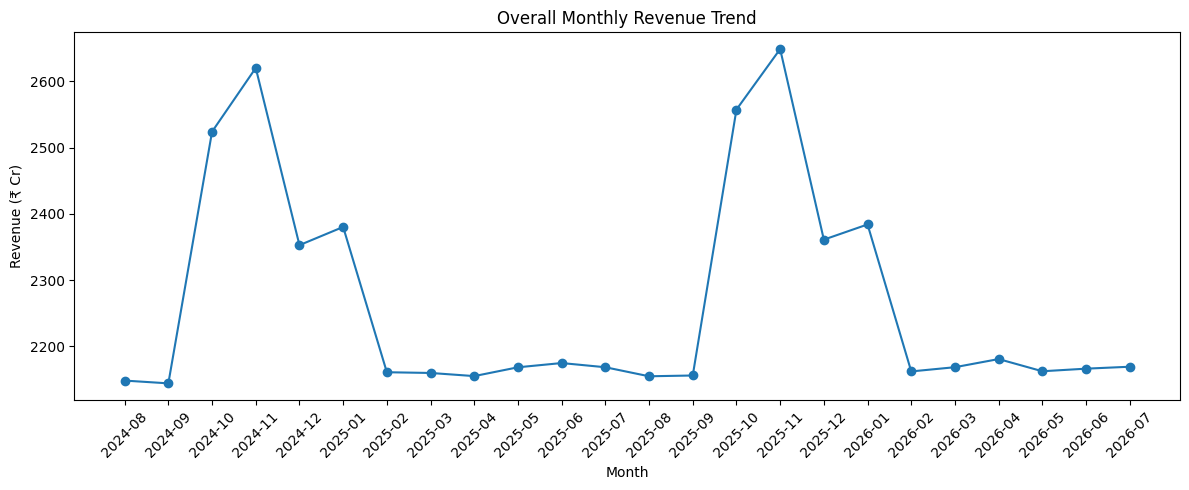

In [22]:
orders = pd.read_csv("orders.csv")
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']
orders['month'] = orders['order_date'].dt.to_period('M')

monthly = orders.groupby('month')['revenue'].sum() / 1e7

plt.figure(figsize=(12,5))
plt.plot(monthly.index.astype(str), monthly.values, marker='o')
plt.xticks(rotation=45)
plt.xlabel("Month")
plt.ylabel("Revenue (₹ Cr)")
plt.title("Overall Monthly Revenue Trend")
plt.tight_layout()
plt.show()

In [32]:
print(monthly.round(2))

month
2024-08    1708.81
2024-09    1706.15
2024-10    2006.51
2024-11    2082.19
2024-12    1869.15
2025-01    1892.19
2025-02    1718.21
2025-03    1716.64
2025-04    1714.04
2025-05    1723.23
2025-06    1727.42
2025-07    1722.13
2025-08    1712.05
2025-09    1713.13
2025-10    2034.05
2025-11    2103.78
2025-12    1877.55
2026-01    1893.60
2026-02    1717.74
2026-03    1722.73
2026-04    1730.80
2026-05    1717.23
2026-06    1719.79
2026-07    1722.87
Freq: M, Name: revenue, dtype: float64


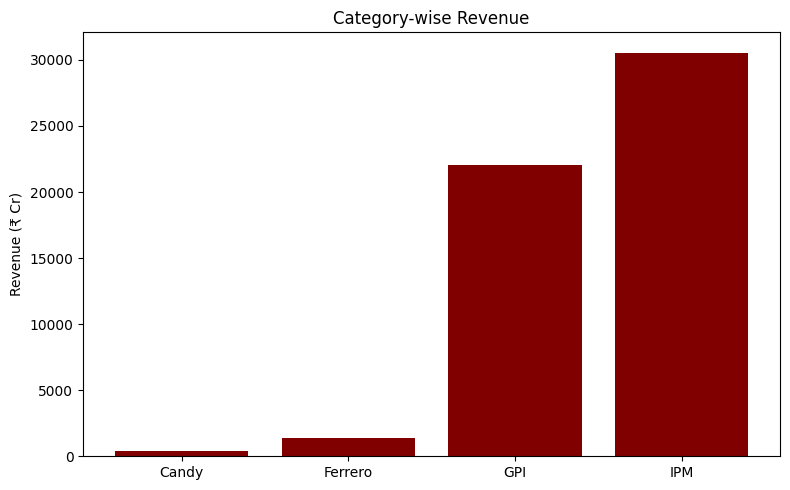

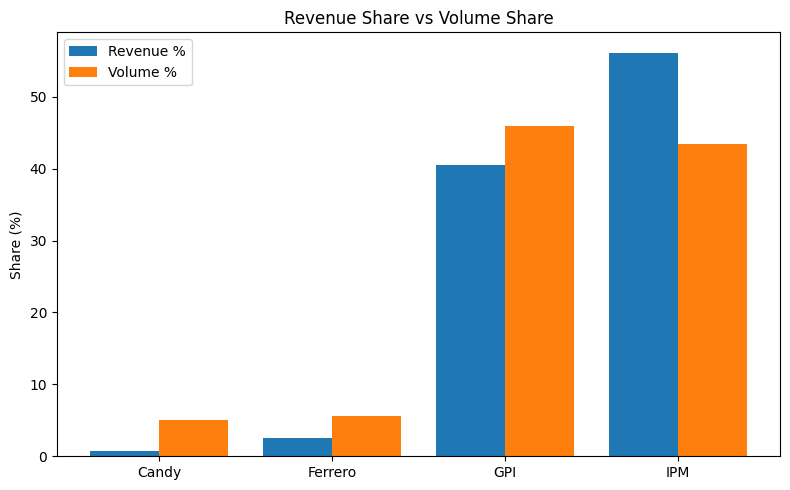

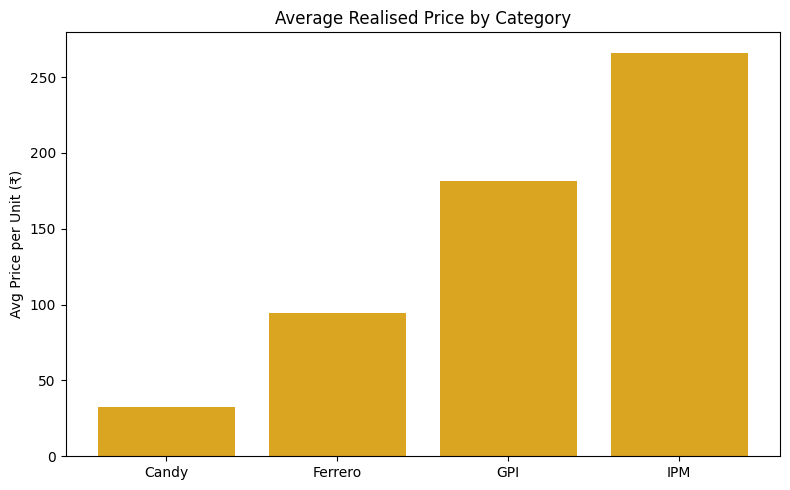

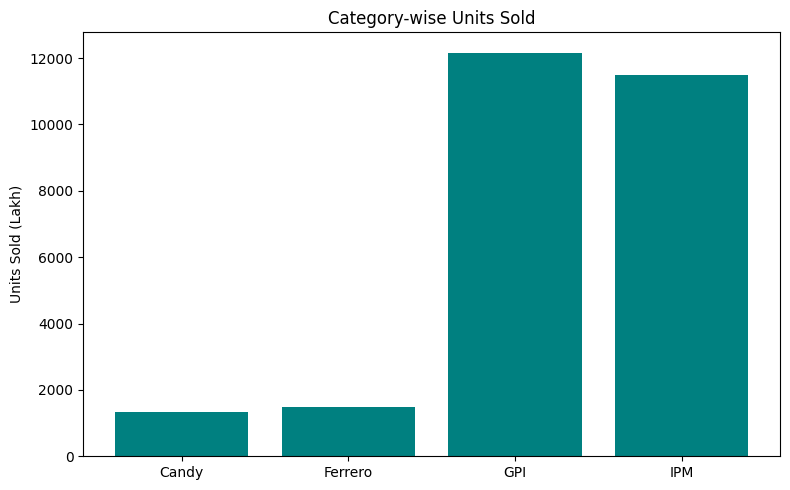

In [23]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

orders = orders.merge(products[['sku_id','category_name']], on='sku_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

cat = orders.groupby('category_name').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)

cat['revenue_pct'] = cat['revenue'] / cat['revenue'].sum() * 100
cat['volume_pct'] = cat['units'] / cat['units'].sum() * 100
cat['avg_price'] = cat['revenue'] / cat['units']

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['revenue']/1e7, color='maroon')
plt.ylabel("Revenue (₹ Cr)")
plt.title("Category-wise Revenue")
plt.tight_layout()
plt.show()

x = range(len(cat))
plt.figure(figsize=(8,5))
plt.bar(x, cat['revenue_pct'], width=0.4, label='Revenue %', align='center')
plt.bar([i+0.4 for i in x], cat['volume_pct'], width=0.4, label='Volume %', align='center')
plt.xticks([i+0.2 for i in x], cat.index)
plt.ylabel("Share (%)")
plt.title("Revenue Share vs Volume Share")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['avg_price'], color='goldenrod')
plt.ylabel("Avg Price per Unit (₹)")
plt.title("Average Realised Price by Category")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(cat.index, cat['units']/1e5, color='teal')
plt.ylabel("Units Sold (Lakh)")
plt.title("Category-wise Units Sold")
plt.tight_layout()
plt.show()

In [25]:
print(cat[['revenue','units','revenue_pct','volume_pct','avg_price']].round(2))

                    revenue       units  revenue_pct  volume_pct  avg_price
category_name                                                              
Candy          4.293628e+09   132423599         0.79        5.00      32.42
Ferrero        1.402836e+10   148484109         2.58        5.61      94.48
GPI            2.204026e+11  1216773729        40.49       45.99     181.14
IPM            3.055870e+11  1148159690        56.14       43.39     266.15


                   revenue       units  outlets  revenue_pct  units_pct  \
channel_type                                                              
Dealer        3.240797e+11  1575079822    37603        59.54      59.53   
Hawkers       2.499612e+10   121588688     9432         4.59       4.60   
Modern Trade  1.063539e+10    51694583     2312         1.95       1.95   
Retail        1.846003e+11   897478034   757180        33.91      33.92   

              outlet_pct  revenue_per_outlet  units_per_outlet  
channel_type                                                    
Dealer              4.66          8618453.43          41887.08  
Hawkers             1.17          2650139.93          12891.08  
Modern Trade        0.29          4600081.20          22359.25  
Retail             93.88           243799.81           1185.29  


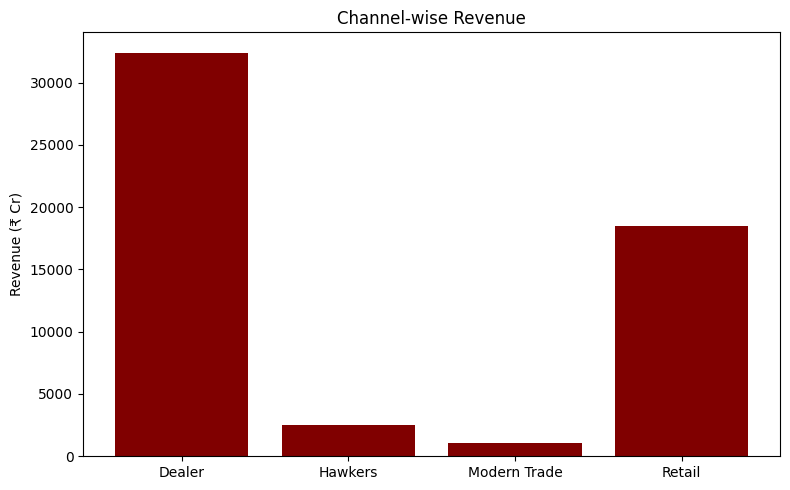

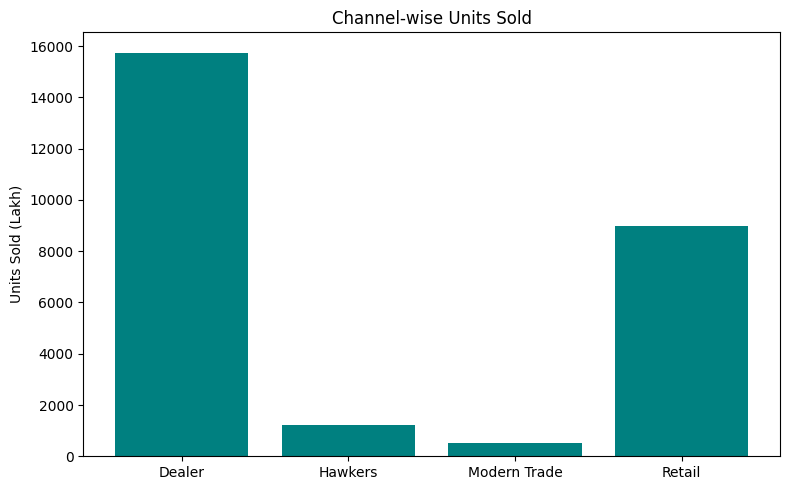

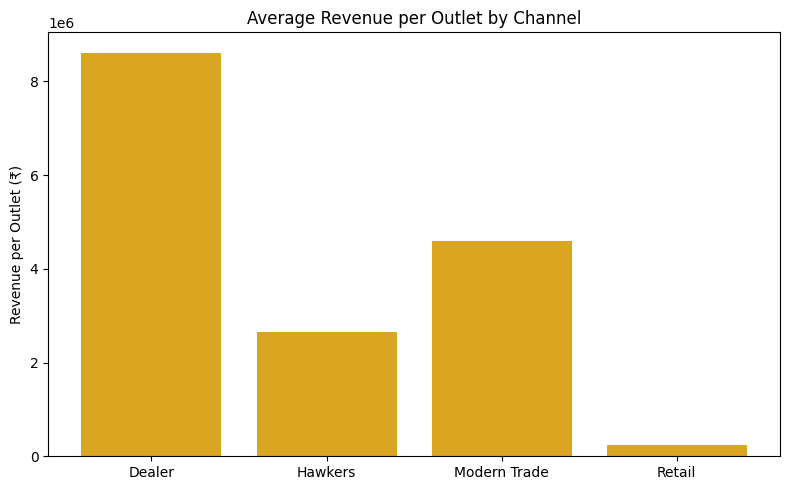

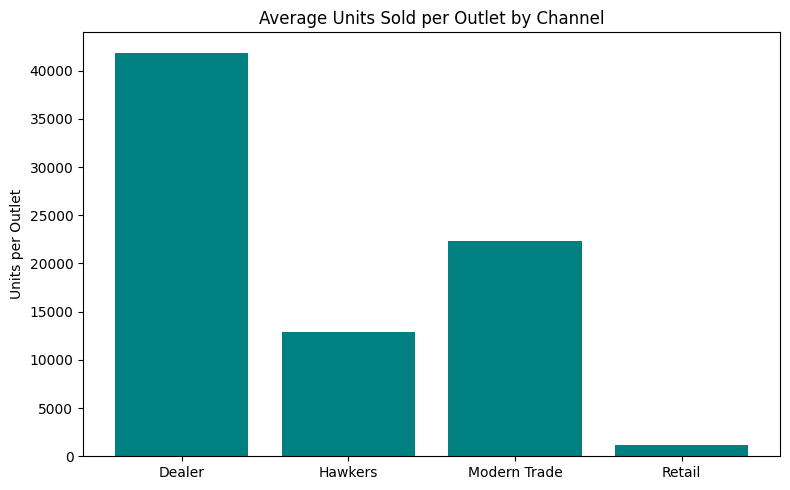

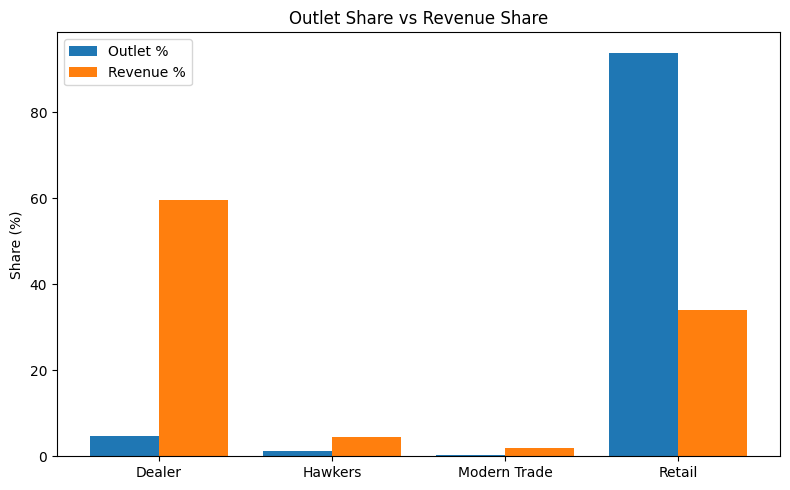

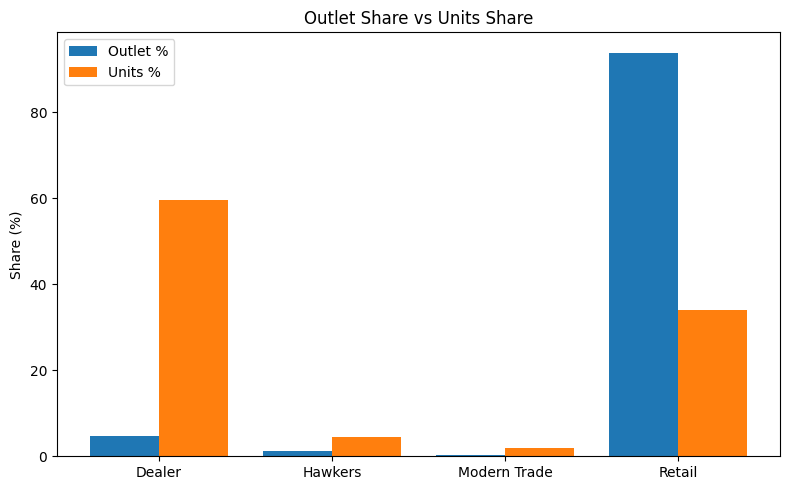

In [26]:
orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','channel_type']], on='outlet_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

outlet_counts = outlets.groupby('channel_type')['outlet_id'].nunique()

ch = orders.groupby('channel_type').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)
ch['outlets'] = outlet_counts
ch['revenue_pct'] = ch['revenue'] / ch['revenue'].sum() * 100
ch['units_pct'] = ch['units'] / ch['units'].sum() * 100
ch['outlet_pct'] = ch['outlets'] / ch['outlets'].sum() * 100
ch['revenue_per_outlet'] = ch['revenue'] / ch['outlets']
ch['units_per_outlet'] = ch['units'] / ch['outlets']

print(ch.round(2))

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['revenue']/1e7, color='maroon')
plt.ylabel("Revenue (₹ Cr)")
plt.title("Channel-wise Revenue")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['units']/1e5, color='teal')
plt.ylabel("Units Sold (Lakh)")
plt.title("Channel-wise Units Sold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['revenue_per_outlet'], color='goldenrod')
plt.ylabel("Revenue per Outlet (₹)")
plt.title("Average Revenue per Outlet by Channel")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.bar(ch.index, ch['units_per_outlet'], color='teal')
plt.ylabel("Units per Outlet")
plt.title("Average Units Sold per Outlet by Channel")
plt.tight_layout()
plt.show()

x = range(len(ch))
plt.figure(figsize=(8,5))
plt.bar(x, ch['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], ch['revenue_pct'], width=0.4, label='Revenue %')
plt.xticks([i+0.2 for i in x], ch.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Revenue Share")
plt.legend()
plt.tight_layout()
plt.show()

x = range(len(ch))
plt.figure(figsize=(8,5))
plt.bar(x, ch['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], ch['units_pct'], width=0.4, label='Units %')
plt.xticks([i+0.2 for i in x], ch.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Units Share")
plt.legend()
plt.tight_layout()

plt.show()

                  revenue       units  outlets  revenue_pct  outlet_pct  \
outlet_tier                                                               
Bronze       2.080685e+11  1011584264   362387        38.23       44.93   
Gold         1.411856e+11   686516868   161552        25.94       20.03   
Silver       1.950574e+11   947739995   282588        35.84       35.04   

             revenue_per_outlet  
outlet_tier                      
Bronze                574161.08  
Gold                  873933.06  
Silver                690253.69  


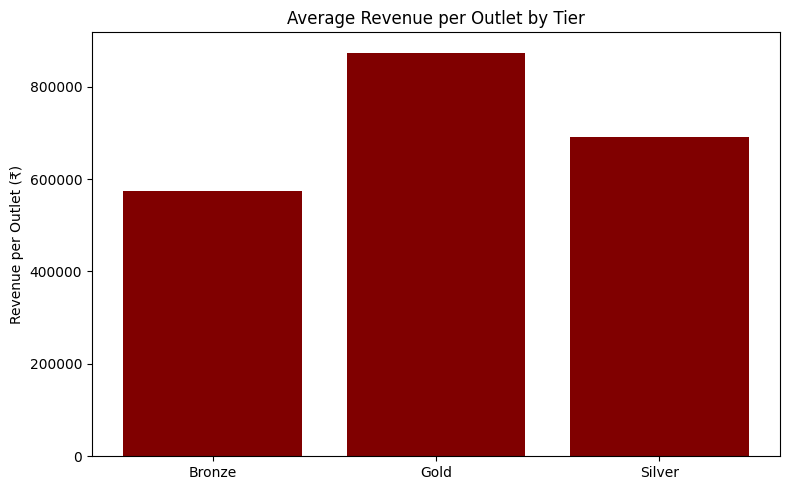

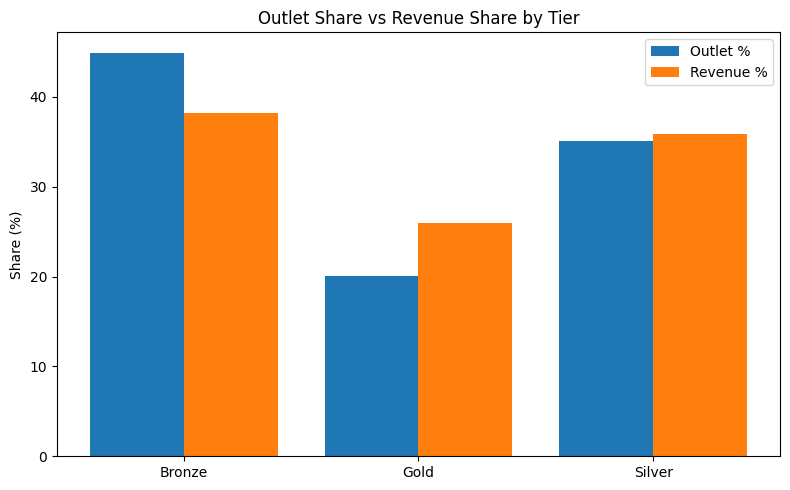

In [27]:
orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','outlet_tier']], on='outlet_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

outlet_counts = outlets.groupby('outlet_tier')['outlet_id'].nunique()

tier = orders.groupby('outlet_tier').agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
)
tier['outlets'] = outlet_counts
tier['revenue_pct'] = tier['revenue'] / tier['revenue'].sum() * 100
tier['outlet_pct'] = tier['outlets'] / tier['outlets'].sum() * 100
tier['revenue_per_outlet'] = tier['revenue'] / tier['outlets']

print(tier.round(2))

plt.figure(figsize=(8,5))
plt.bar(tier.index, tier['revenue_per_outlet'], color='maroon')
plt.ylabel("Revenue per Outlet (₹)")
plt.title("Average Revenue per Outlet by Tier")
plt.tight_layout()
plt.show()

x = range(len(tier))
plt.figure(figsize=(8,5))
plt.bar(x, tier['outlet_pct'], width=0.4, label='Outlet %')
plt.bar([i+0.4 for i in x], tier['revenue_pct'], width=0.4, label='Revenue %')
plt.xticks([i+0.2 for i in x], tier.index)
plt.ylabel("Share (%)")
plt.title("Outlet Share vs Revenue Share by Tier")
plt.legend()
plt.tight_layout()
plt.show()

Top 10 SKUs
                  sku_name category_name      units       revenue
40         Marlboro Pack 1           IPM  737287419  2.007707e+11
0   GPI_Franchise_1 Pack 1           GPI  232451667  6.959603e+10
20  GPI_Franchise_4 Pack 1           GPI  231776928  4.050534e+10
41         Marlboro Pack 2           IPM  102845682  4.010673e+10
44         Marlboro Pack 5           IPM  102438950  2.939998e+10
7   GPI_Franchise_2 Pack 1           GPI  231295251  2.856265e+10
42         Marlboro Pack 3           IPM  102881624  2.239630e+10
15  GPI_Franchise_3 Pack 1           GPI  231600979  2.046658e+10
43         Marlboro Pack 4           IPM  102706015  1.291323e+10
47           TicTac Pack 3       Ferrero   21318200  2.741094e+09
Bottom 10 SKUs
                    sku_name category_name     units       revenue
27    GPI_Franchise_5 Pack 1           GPI   8077772  8.633523e+08
32    GPI_Franchise_5 Pack 6           GPI   8048128  8.471460e+08
58  Candy_Franchise_2 Pack 4         Candy  18

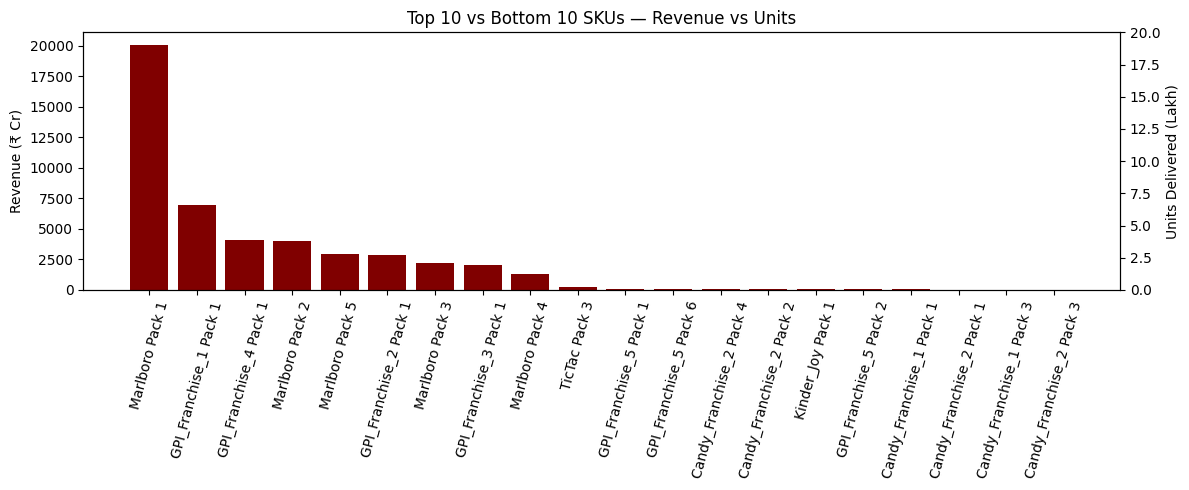

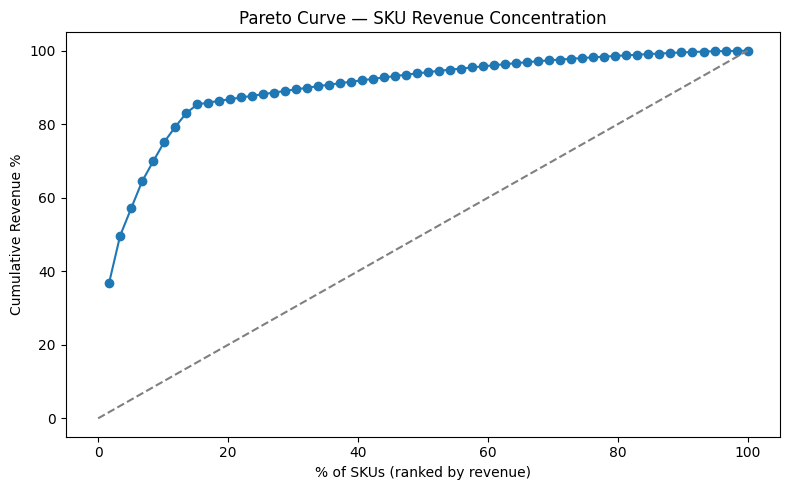

In [28]:
orders = pd.read_csv("orders.csv")
products = pd.read_csv("products.csv")

orders = orders.merge(products[['sku_id','sku_name','category_name']], on='sku_id')
orders['revenue'] = orders['qty_delivered'] * orders['unit_price']

sku = orders.groupby(['sku_id','sku_name','category_name']).agg(
    revenue=('revenue','sum'),
    units=('qty_delivered','sum')
).reset_index()

sku = sku.sort_values('revenue', ascending=False)

print("Top 10 SKUs")
print(sku.head(10)[['sku_name','category_name','units','revenue']].round(2))

print("Bottom 10 SKUs")
print(sku.tail(10)[['sku_name','category_name','units','revenue']].round(2))

print("Units Variation:", (sku['units'].std() / sku['units'].mean()).round(3))
print("Revenue Variation:", (sku['revenue'].std() / sku['revenue'].mean()).round(3))

top10 = sku.head(10)
bottom10 = sku.tail(10)
combo = pd.concat([top10, bottom10])
combo['units_lakh'] = combo['units'] / 1e5

fig, ax1 = plt.subplots(figsize=(12,5))
ax1.bar(combo['sku_name'], combo['revenue']/1e7, color='maroon')
ax1.set_ylabel("Revenue (₹ Cr)")
plt.xticks(rotation=75)

ax2 = ax1.twinx()
ax2.plot(combo['sku_name'], combo['units_lakh'], color='goldenrod', marker='o')
ax2.set_ylabel("Units Delivered (Lakh)")
ax2.set_ylim(0, 20)
plt.title("Top 10 vs Bottom 10 SKUs — Revenue vs Units")
plt.tight_layout()
plt.show()

sku_sorted = sku.sort_values('revenue', ascending=False).reset_index(drop=True)
sku_sorted['cum_revenue_pct'] = sku_sorted['revenue'].cumsum() / sku_sorted['revenue'].sum() * 100
sku_sorted['sku_rank_pct'] = (sku_sorted.index+1) / len(sku_sorted) * 100

plt.figure(figsize=(8,5))
plt.plot(sku_sorted['sku_rank_pct'], sku_sorted['cum_revenue_pct'], marker='o')
plt.plot([0,100],[0,100], linestyle='--', color='gray')
plt.xlabel("% of SKUs (ranked by revenue)")
plt.ylabel("Cumulative Revenue %")
plt.title("Pareto Curve — SKU Revenue Concentration")
plt.tight_layout()
plt.show()

productivity vs dropsize correlation: 0.605
OOS% vs Service Level correlation: -0.428


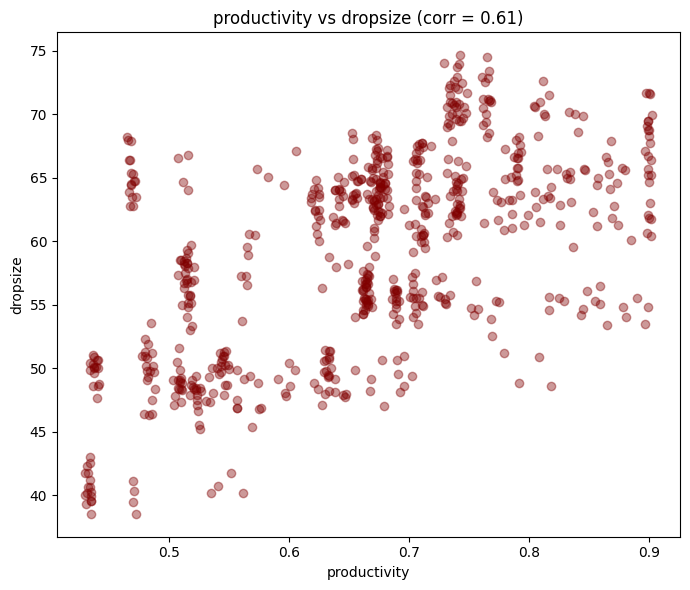

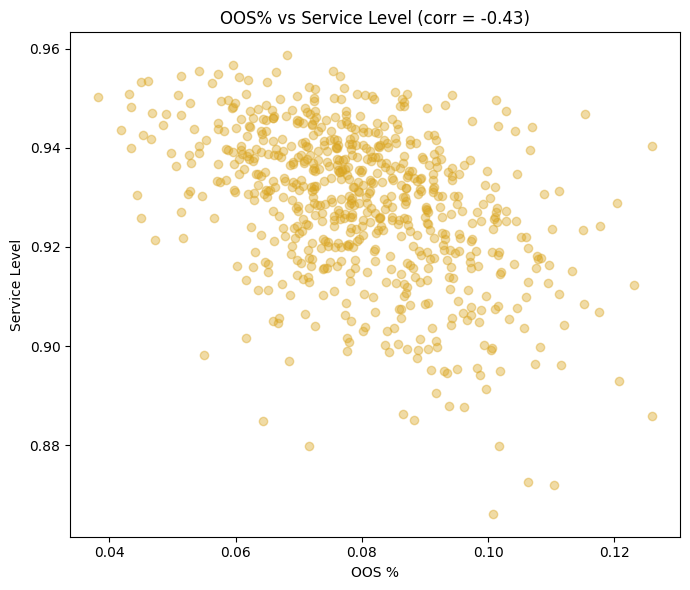

In [29]:
kpi_state = pd.read_csv("kpi_state_month.csv")
kpi_cat = pd.read_csv("kpi_state_month_category.csv")

kpi_cat_avg = kpi_cat.groupby(['state_name','month'])['oos_pct'].mean().reset_index()

merged = kpi_state.merge(kpi_cat_avg, on=['state_name','month'])

corr1 = merged['productivity'].corr(merged['dropsize'])
corr2 = merged['oos_pct'].corr(merged['service_level'])

print("productivity vs dropsize correlation:", round(corr1,3))
print("OOS% vs Service Level correlation:", round(corr2,3))

plt.figure(figsize=(7,6))
plt.scatter(merged['productivity'], merged['dropsize'], alpha=0.4, color='maroon')
plt.xlabel("productivity")
plt.ylabel("dropsize")
plt.title(f"productivity vs dropsize (corr = {round(corr1,2)})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,6))
plt.scatter(merged['oos_pct'], merged['service_level'], alpha=0.4, color='goldenrod')
plt.xlabel("OOS %")
plt.ylabel("Service Level")
plt.title(f"OOS% vs Service Level (corr = {round(corr2,2)})")
plt.tight_layout()
plt.show()

In [30]:
outlets = pd.read_csv("outlets.csv")
orders = pd.read_csv("orders.csv")
visits = pd.read_csv("visits.csv")

outlets['closure_date'] = pd.to_datetime(outlets['closure_date'])
orders['order_date'] = pd.to_datetime(orders['order_date'])
visits['visit_date'] = pd.to_datetime(visits['visit_date'])

inactive_outlets = outlets[outlets['is_active'] == False][['outlet_id','closure_date']]

orders_check = orders.merge(inactive_outlets, on='outlet_id')
visits_check = visits.merge(inactive_outlets, on='outlet_id')

orders_after_closure = orders_check[orders_check['order_date'] >= orders_check['closure_date']]
visits_after_closure = visits_check[visits_check['visit_date'] >= visits_check['closure_date']]

print("Total inactive outlets:", len(inactive_outlets))
print("Orders after closure_date:", len(orders_after_closure))
print("Visits after closure_date:", len(visits_after_closure))
print("Inactive outlets with orders after closure:", orders_after_closure['outlet_id'].nunique())
print("Inactive outlets with visits after closure:", visits_after_closure['outlet_id'].nunique())

Total inactive outlets: 77735
Orders after closure_date: 0
Visits after closure_date: 0
Inactive outlets with orders after closure: 0
Inactive outlets with visits after closure: 0


In [33]:
orders_after = orders_check[
    orders_check['order_date'] > orders_check['closure_date']
]

visits_after = visits_check[
    visits_check['visit_date'] > visits_check['closure_date']
]

print(len(orders_after))
print(len(visits_after))

0
0


In [34]:
outlet_id = "OUT000001"  

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")
products = pd.read_csv("products.csv")
visits = pd.read_csv("visits.csv")

orders = orders.merge(products[['sku_id','category_name','sku_name']], on='sku_id')

successful_visits = visits[visits['visit_outcome'] == 'Order Placed']['visit_id']

outlet_orders = orders[
    (orders['outlet_id'] == outlet_id) &
    (orders['visit_id'].isin(successful_visits))
]

print(f"Outlet: {outlet_id}")
print(f"Total successful visits: {outlet_orders['visit_id'].nunique()}")
print(f"Total order lines: {len(outlet_orders)}")
print()

print("Category-wise units sold:")
cat_split = outlet_orders.groupby('category_name')['qty_delivered'].sum()
print(cat_split)
print()

print("SKU-wise breakdown:")
sku_split = outlet_orders.groupby(['category_name','sku_name'])['qty_delivered'].sum().reset_index()
print(sku_split.sort_values('qty_delivered', ascending=False).to_string(index=False))

Outlet: OUT000001
Total successful visits: 28
Total order lines: 129

Category-wise units sold:
category_name
Candy        97
Ferrero     204
GPI        1121
IPM         829
Name: qty_delivered, dtype: int64

SKU-wise breakdown:
category_name                 sku_name  qty_delivered
          IPM          Marlboro Pack 1            531
          GPI   GPI_Franchise_3 Pack 1            365
          GPI   GPI_Franchise_1 Pack 1            299
          IPM          Marlboro Pack 2            161
          GPI   GPI_Franchise_2 Pack 1            120
          GPI   GPI_Franchise_4 Pack 1            103
      Ferrero            TicTac Pack 1             78
      Ferrero            TicTac Pack 2             63
          IPM          Marlboro Pack 4             60
          IPM          Marlboro Pack 5             47
          IPM          Marlboro Pack 3             30
        Candy Candy_Franchise_2 Pack 2             29
          GPI   GPI_Franchise_4 Pack 3             29
      Ferrero  

Total units sold per outlet — Tier x Channel:
                             mean   median   min     max  outlets
outlet_tier channel_type                                         
Bronze      Dealer        37046.9  36910.0  4037   89017    16223
            Hawkers       11278.0  11260.0  2729   24089     4133
            Modern Trade  20429.9  20544.0  4543   42194      959
            Retail         1125.5   1124.0    68    2766   305968
Gold        Dealer        55547.0  55569.0  8934  121680     7402
            Hawkers       16940.2  16819.5  2798   33351     1882
            Modern Trade  30183.6  29628.0  9765   58163      435
            Retail         1687.5   1683.0   146    3999   136498
Silver      Dealer        44739.2  44597.0  4291  104227    12582
            Hawkers       13607.6  13456.0  2762   29205     3167
            Modern Trade  24323.7  24780.5  5882   49177      780
            Retail         1351.8   1351.0    97    3497   238763


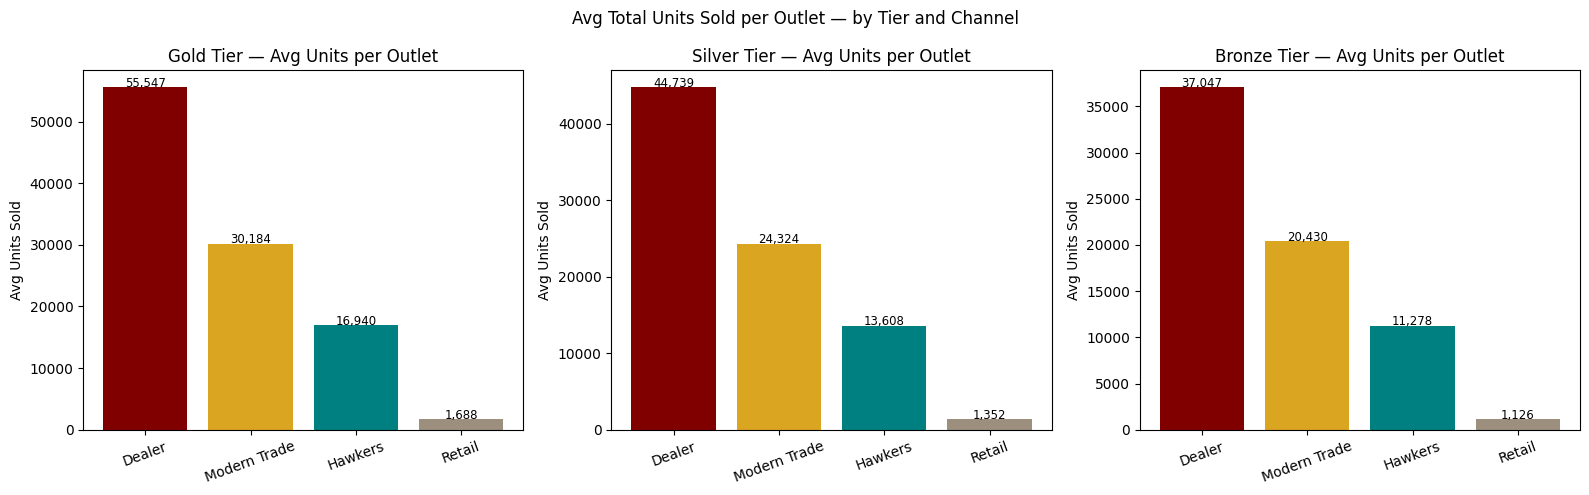

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','outlet_tier','channel_type']], on='outlet_id')

total_units = orders.groupby(['outlet_id','outlet_tier','channel_type'])['qty_delivered'].sum().reset_index()
total_units.columns = ['outlet_id','outlet_tier','channel_type','total_units']

benchmark = total_units.groupby(['outlet_tier','channel_type'])['total_units'].agg(
    mean='mean',
    median='median',
    min='min',
    max='max',
    outlets='count'
).round(1)

print("Total units sold per outlet — Tier x Channel:")
print(benchmark.to_string())

tiers = ['Gold','Silver','Bronze']
colors = ['#C9932A','#9C8F7E','#7A1F33']
channels = total_units['channel_type'].unique()

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, tier in enumerate(tiers):
    data = total_units[total_units['outlet_tier'] == tier]
    ax = axes[i]
    ch_means = data.groupby('channel_type')['total_units'].mean().sort_values(ascending=False)
    bars = ax.bar(ch_means.index, ch_means.values, color=['maroon','goldenrod','teal','#9C8F7E'][:len(ch_means)])
    for b, v in zip(bars, ch_means.values):
        ax.text(b.get_x()+b.get_width()/2, v+50, f"{v:,.0f}", ha='center', fontsize=8.5)
    ax.set_title(f"{tier} Tier — Avg Units per Outlet")
    ax.set_ylabel("Avg Units Sold")
    ax.tick_params(axis='x', rotation=20)

plt.suptitle("Avg Total Units Sold per Outlet — by Tier and Channel", fontsize=12)
plt.tight_layout()
plt.show()

Total Units Sold (Lakh) — Tier x Channel:
channel_type   Dealer  Hawkers  Modern Trade   Retail
outlet_tier                                          
Bronze        6010.13   466.12        195.92  3443.68
Gold          4111.59   318.82        131.30  2303.47
Silver        5629.08   430.95        189.72  3227.64


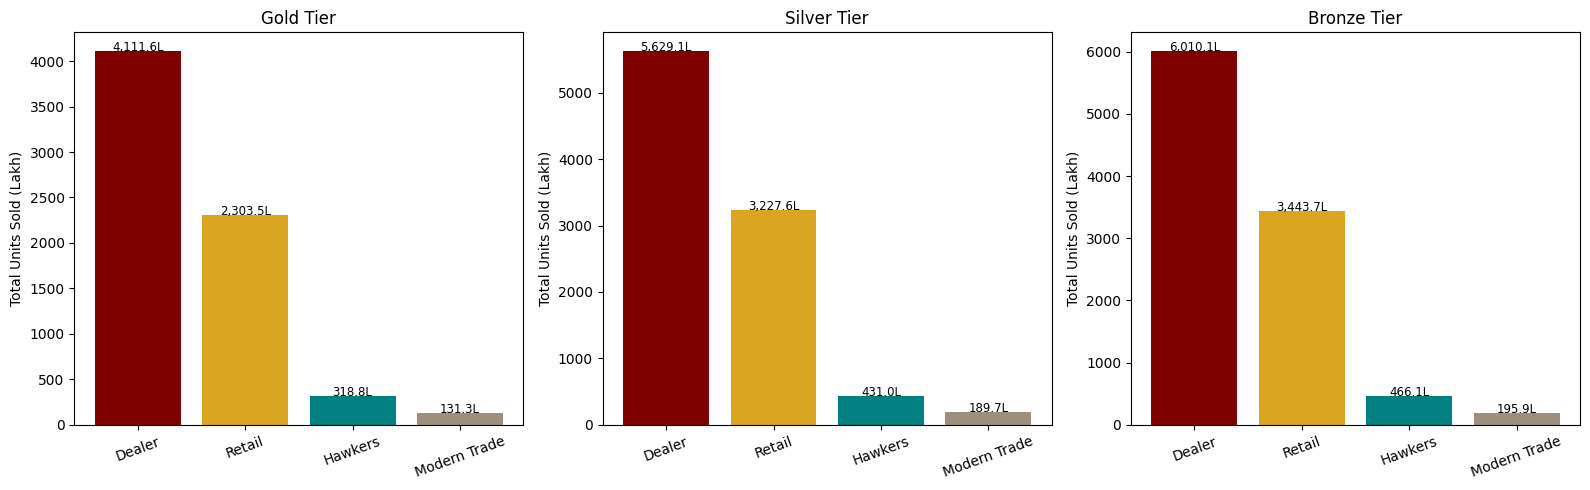

In [36]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")

orders = orders.merge(outlets[['outlet_id','outlet_tier','channel_type']], on='outlet_id')

benchmark = orders.groupby(['outlet_tier','channel_type'])['qty_delivered'].sum().unstack(fill_value=0)
benchmark = benchmark / 1e5  # lakh mein

print("Total Units Sold (Lakh) — Tier x Channel:")
print(benchmark.round(2))

tiers = ['Gold','Silver','Bronze']
colors = ['maroon','goldenrod','teal','#9C8F7E']

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for i, tier in enumerate(tiers):
    ax = axes[i]
    if tier in benchmark.index:
        data = benchmark.loc[tier].sort_values(ascending=False)
        bars = ax.bar(data.index, data.values, color=colors[:len(data)])
        for b, v in zip(bars, data.values):
            ax.text(b.get_x()+b.get_width()/2, v+0.5, f"{v:,.1f}L", ha='center', fontsize=8.5)
        ax.set_title(f"{tier} Tier")
        ax.set_ylabel("Total Units Sold (Lakh)")
        ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

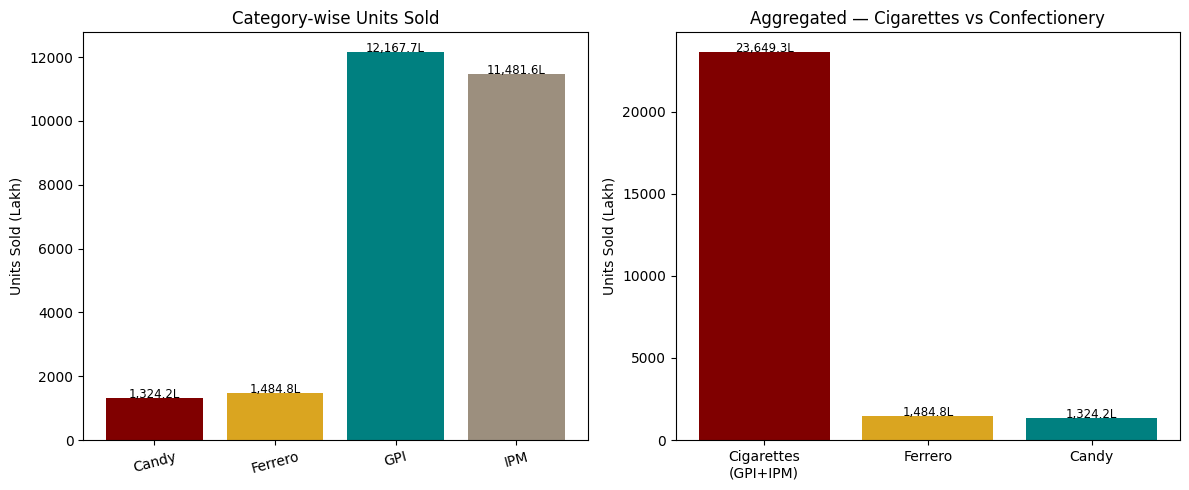

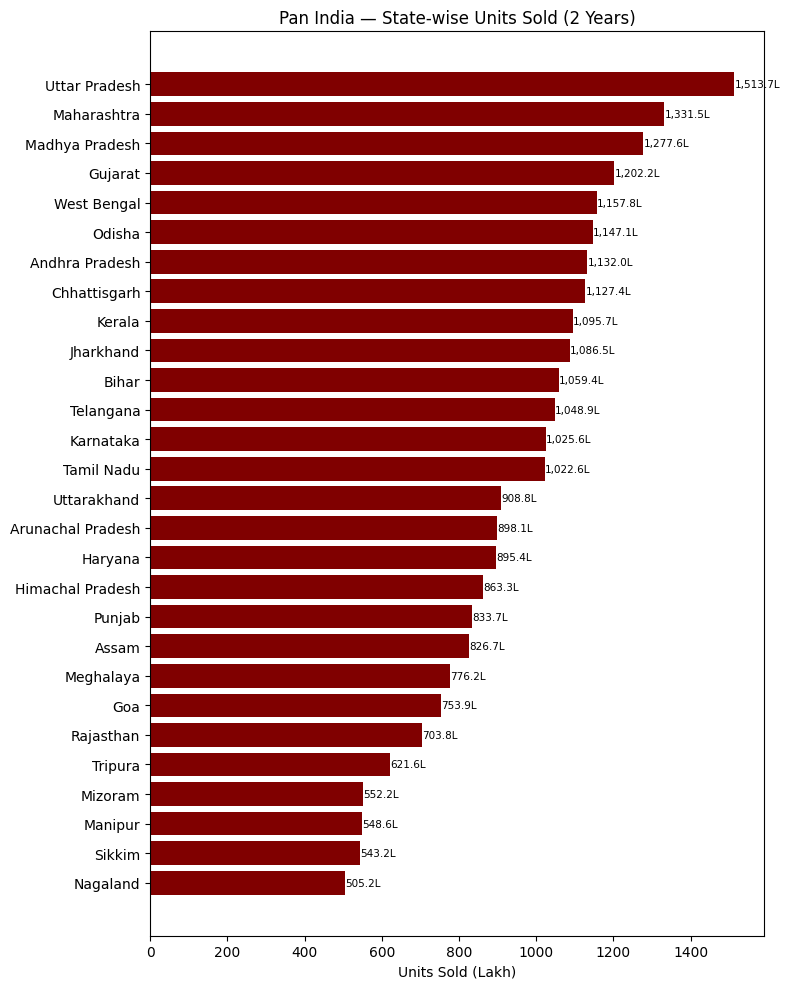

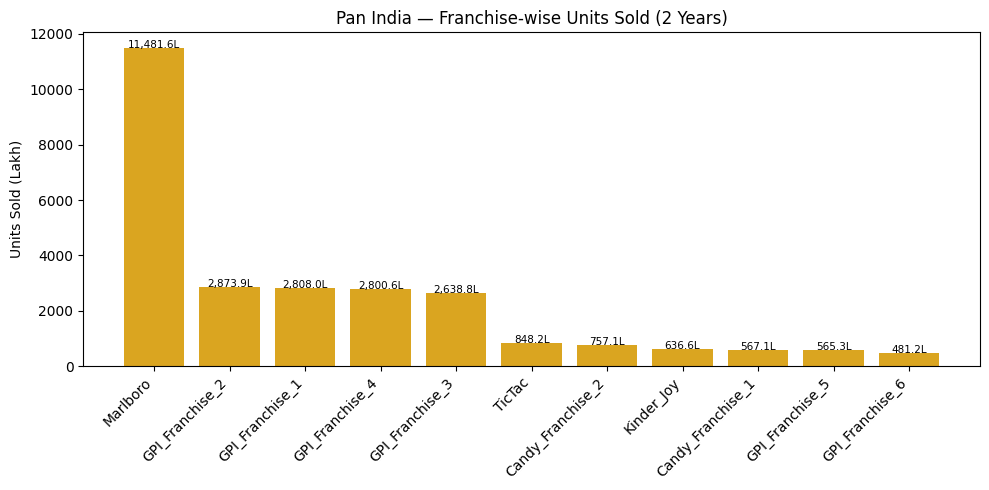

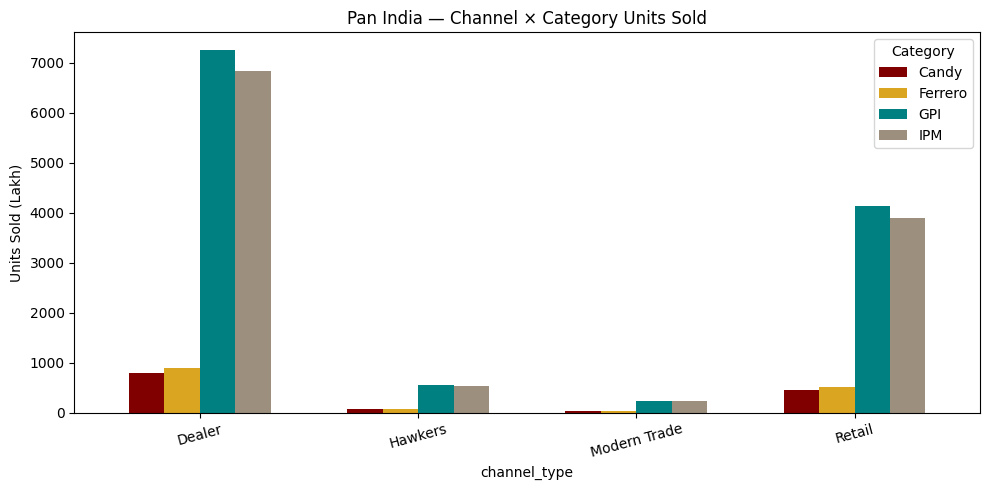

=== Category-wise Units (Lakh) ===
category_name
Candy       1324.24
Ferrero     1484.84
GPI        12167.74
IPM        11481.60
Name: qty_delivered, dtype: float64

Cigarettes (GPI+IPM): 23,649.33L

=== State-wise Units (Lakh) ===
state_name
Uttar Pradesh        1513.70
Maharashtra          1331.45
Madhya Pradesh       1277.58
Gujarat              1202.24
West Bengal          1157.75
Odisha               1147.09
Andhra Pradesh       1132.05
Chhattisgarh         1127.42
Kerala               1095.69
Jharkhand            1086.50
Bihar                1059.45
Telangana            1048.93
Karnataka            1025.56
Tamil Nadu           1022.57
Uttarakhand           908.75
Arunachal Pradesh     898.11
Haryana               895.35
Himachal Pradesh      863.26
Punjab                833.68
Assam                 826.73
Meghalaya             776.16
Goa                   753.87
Rajasthan             703.77
Tripura               621.58
Mizoram               552.18
Manipur               548.58
Sik

In [37]:
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("orders.csv")
outlets = pd.read_csv("outlets.csv")
products = pd.read_csv("products.csv")

orders = orders.merge(products[['sku_id','category_name','franchise_name']], on='sku_id')
orders = orders.merge(outlets[['outlet_id','channel_type','state_name']], on='outlet_id')

# ============================================================
# 1. Category-wise units sold + cigarette aggregate
# ============================================================
cat_units = orders.groupby('category_name')['qty_delivered'].sum()

cig_total = cat_units.get('GPI', 0) + cat_units.get('IPM', 0)
cat_plot = cat_units.copy()
cat_plot['Cigarettes (GPI+IPM)'] = cig_total

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

cat_units_lakh = cat_units / 1e5
ax1.bar(cat_units_lakh.index, cat_units_lakh.values,
        color=['maroon','goldenrod','teal','#9C8F7E'])
for i, v in enumerate(cat_units_lakh.values):
    ax1.text(i, v+0.5, f"{v:,.1f}L", ha='center', fontsize=8.5)
ax1.set_ylabel("Units Sold (Lakh)")
ax1.set_title("Category-wise Units Sold")
ax1.tick_params(axis='x', rotation=15)

agg_data = {
    'Cigarettes\n(GPI+IPM)': cig_total/1e5,
    'Ferrero': cat_units.get('Ferrero', 0)/1e5,
    'Candy': cat_units.get('Candy', 0)/1e5
}
ax2.bar(agg_data.keys(), agg_data.values(),
        color=['maroon','goldenrod','teal'])
for i, (k, v) in enumerate(agg_data.items()):
    ax2.text(i, v+0.5, f"{v:,.1f}L", ha='center', fontsize=8.5)
ax2.set_ylabel("Units Sold (Lakh)")
ax2.set_title("Aggregated — Cigarettes vs Confectionery")
plt.tight_layout()
plt.show()

# ============================================================
# 2. State-wise units sold (2 years)
# ============================================================
state_units = orders.groupby('state_name')['qty_delivered'].sum().sort_values(ascending=True) / 1e5

plt.figure(figsize=(8, 10))
bars = plt.barh(state_units.index, state_units.values, color='maroon')
for b, v in zip(bars, state_units.values):
    plt.text(v+0.5, b.get_y()+b.get_height()/2,
             f"{v:,.1f}L", va='center', fontsize=7.5)
plt.xlabel("Units Sold (Lakh)")
plt.title("Pan India — State-wise Units Sold (2 Years)")
plt.tight_layout()
plt.show()

# ============================================================
# 3. Franchise-wise units sold (2 years)
# ============================================================
franchise_units = orders.groupby('franchise_name')['qty_delivered'].sum().sort_values(ascending=False) / 1e5

plt.figure(figsize=(10, 5))
bars = plt.bar(franchise_units.index, franchise_units.values,
               color='goldenrod')
for b, v in zip(bars, franchise_units.values):
    plt.text(b.get_x()+b.get_width()/2, v+0.3,
             f"{v:,.1f}L", ha='center', fontsize=7.5)
plt.ylabel("Units Sold (Lakh)")
plt.title("Pan India — Franchise-wise Units Sold (2 Years)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# ============================================================
# 4. Channel x Category units sold
# ============================================================
ch_cat = orders.groupby(['channel_type','category_name'])['qty_delivered'].sum().unstack(fill_value=0) / 1e5

colors = ['maroon','goldenrod','teal','#9C8F7E']
ch_cat.plot(kind='bar', figsize=(10, 5), color=colors, width=0.65)
plt.ylabel("Units Sold (Lakh)")
plt.title("Pan India — Channel × Category Units Sold")
plt.xticks(rotation=15)
plt.legend(title="Category")
plt.tight_layout()
plt.show()

# ============================================================
# Factual data print
# ============================================================
print("=== Category-wise Units (Lakh) ===")
print((cat_units/1e5).round(2))
print(f"\nCigarettes (GPI+IPM): {cig_total/1e5:,.2f}L")

print("\n=== State-wise Units (Lakh) ===")
print((state_units.sort_values(ascending=False)).round(2))

print("\n=== Franchise-wise Units (Lakh) ===")
print(franchise_units.round(2))

print("\n=== Channel x Category Units (Lakh) ===")
print(ch_cat.round(2))

In [38]:
import pandas as pd
import numpy as np

# Load data (adjust paths/column names if different)
orders = pd.read_csv("orders.csv", usecols=["outlet_id","qty_delivered"])
outlets = pd.read_csv("outlets.csv", usecols=["outlet_id","channel_type","outlet_tier"])  # use 'tier' if pre-assigned; otherwise ensure 'tier' column exists after ranking

# 1) total units per outlet
units = orders.groupby("outlet_id", as_index=False)["qty_delivered"].sum().rename(columns={"qty_delivered":"total_units"})
units = units.merge(outlets, on="outlet_id", how="left")

# Check used channel names mapping (normalize capitalization)
units["channel_type"] = units["channel_type"].str.strip().str.title()
units["outlet_tier"] = units["outlet_tier"].str.strip().str.title()

# A: Per-outlet mean by channel (all tiers combined)
chan_summary = units.groupby("channel_type").agg(
    outlet_count=("outlet_id","nunique"),
    units_total=("total_units","sum"),
    units_mean=("total_units","mean"),
    units_median=("total_units","median")
).reset_index().sort_values("units_mean", ascending=False)
print("\nPer-outlet channel summary (descending by mean):")
print(chan_summary.to_string(index=False))

# Desired per-outlet ordering (desc): Dealer > Modern Trade > Hawkers > Retail
desired_per_outlet_order = ["Dealer","Modern Trade","Hawkers","Retail"]
actual_order = list(chan_summary["channel_type"])
print("\nActual per-outlet order:", actual_order)
print("Desired per-outlet order:", desired_per_outlet_order)

# Check if actual ordering meets desired (allow exact match)
meets_per_outlet = actual_order == desired_per_outlet_order
print("\nPer-outlet ordering OK?:", meets_per_outlet)

# B: Within each channel: check Gold > Silver > Bronze (by mean per-outlet)
tier_failures = []
per_channel_tier_stats = []
for ch, df_ch in units.groupby("channel_type"):
    # ensure tier assignment exists
    if df_ch["outlet_tier"].isnull().any():
        print(f"Warning: some outlets in channel {ch} missing tier")
    stats = df_ch.groupby("outlet_tier").agg(
        outlet_count=("outlet_id","nunique"),
        units_total=("total_units","sum"),
        units_mean=("total_units","mean"),
        units_median=("total_units","median")
    ).reset_index()
    per_channel_tier_stats.append((ch, stats))
    # require Gold > Silver > Bronze by mean (if all exist)
    s = stats.set_index("outlet_tier") if not stats.empty else pd.DataFrame()
    for t in ["Gold","Silver","Bronze"]:
        if t not in s.index:
            tier_failures.append((ch, f"Missing tier {t}"))
    try:
        gold_mean = s.loc["Gold","units_mean"]
        silver_mean = s.loc["Silver","units_mean"]
        bronze_mean = s.loc["Bronze","units_mean"]
        if not (gold_mean > silver_mean > bronze_mean):
            tier_failures.append((ch, {"gold_mean":gold_mean,"silver_mean":silver_mean,"bronze_mean":bronze_mean}))
    except Exception:
        pass

print("\nPer-channel tier stats (sample):")
for ch, stats in per_channel_tier_stats:
    print(f"\nChannel: {ch}")
    print(stats.sort_values("units_mean", ascending=False).to_string(index=False))

if tier_failures:
    print("\nTier ordering failures:")
    for f in tier_failures:
        print(f)
else:
    print("\nAll channels: Gold > Silver > Bronze by mean units per outlet.")

# C: Overall channel totals ordering (sum units)
channel_totals = chan_summary.sort_values("units_total", ascending=False)
print("\nChannel totals descending:")
print(channel_totals[["channel_type","units_total"]].to_string(index=False))

desired_total_order = ["Dealer","Retail","Hawkers","Modern Trade"]
actual_total_order = list(channel_totals["channel_type"])
print("\nActual totals order:", actual_total_order)
print("Desired totals order:", desired_total_order)
meets_total_order = actual_total_order == desired_total_order
print("\nOverall totals ordering OK?:", meets_total_order)

# Summary boolean
ok = meets_per_outlet and (not tier_failures) and meets_total_order
print("\nAll hierarchy checks passed?:", ok)


Per-outlet channel summary (descending by mean):
channel_type  outlet_count  units_total   units_mean  units_median
      Dealer         36207   1575079822 43502.080316       42216.0
Modern Trade          2174     51694583 23778.557038       23245.0
     Hawkers          9182    121588688 13242.070137       12833.5
      Retail        681229    897478034  1317.439560        1280.0

Actual per-outlet order: ['Dealer', 'Modern Trade', 'Hawkers', 'Retail']
Desired per-outlet order: ['Dealer', 'Modern Trade', 'Hawkers', 'Retail']

Per-outlet ordering OK?: True

Per-channel tier stats (sample):

Channel: Dealer
outlet_tier  outlet_count  units_total   units_mean  units_median
       Gold          7402    411158932 55547.005134       55569.0
     Silver         12582    562908266 44739.172310       44597.0
     Bronze         16223    601012624 37046.947174       36910.0

Channel: Hawkers
outlet_tier  outlet_count  units_total   units_mean  units_median
       Gold          1882     3188153